In [1]:
#Librerias....
import csv
import os
import cv2
import random
from torchvision import transforms
from torchvision.utils import save_image
from torch import optim, cuda
from torchsummary import summary
import PIL
from PIL import Image
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data.dataloader import default_collate
import torch
from torch.utils.data import DataLoader, ConcatDataset
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch.utils.data import random_split
from torchvision import models
from timeit import default_timer as timer
import cv2
import os
import shutil
import random
from PIL import Image
from skimage.io import imread_collection




In [ ]:
imagenes_brut = imread_collection('Art_Brut/*.jpg')
imagenes_realism = imread_collection('imagenes/Realism/*.jpg')

#directorios donde se encuentran las imagenes 
directorio_brut = "Art_Brut"
directorio_realism = "imagenes/Realism/"

#dIRECTORIOS DE SALIDA

directorio_train_Art = os.path.join ("data3","train","brut")
directorio_train_realism = os.path.join ("data3","train","realism")

directorio_test_Art = os.path.join("data3","test","brut")
directorio_test_realism = os.path.join("data3","test","realism")

directorio_val_Art = os.path.join("data3","val","brut")
directorio_val_realism = os.path.join("data3","val","realism")

#Crear directorios si no existen

for directorio in [directorio_train_Art,directorio_train_realism,directorio_test_Art,directorio_test_realism,directorio_val_Art,directorio_val_realism]:
    if not os.path.exists(directorio):
        os.makedirs(directorio)

im_files_brut = os.listdir(directorio_brut)
im_files_realism = os.listdir(directorio_realism)

# Calcula el tamaño para cada conjunto

def tamaño_conjunto(dataset):
    train_ratio = 0.7
    val_ratio = 0.1
    test_ratio = 0.2
    total_size = len(dataset)
    train_size = int(train_ratio * total_size)
    val_size = int(val_ratio * total_size)
    test_size = total_size - train_size - val_size
    return(total_size,train_size,test_size,val_size)

n,train_size,test_size,val_size = tamaño_conjunto(imagenes_realism)
#m,train_size,test_size,val_size = tamaño_conjunto(imagenes_brut)

im_files_brut = random.sample(im_files_brut, 459)
im_files_realism = random.sample(im_files_realism, 459)

imagenes_train_brut, rest_dataset1 = random_split(im_files_brut, [train_size, n - train_size])
imagenes_val_brut, imagenes_test_brut = random_split(rest_dataset1, [val_size, test_size])

imagenes_train_realism, rest_dataset2 = random_split(im_files_realism, [train_size, n - train_size])
imagenes_val_realism, imagenes_test_realism = random_split(rest_dataset2, [val_size, test_size])


# Mover imágenes de entrenamiento al directorio de entrenamiento
for image_file in imagenes_train_brut:
    ruta_origen = os.path.join(directorio_brut,image_file)
    ruta_destino = os.path.join(directorio_train_Art, image_file)
    shutil.copy(ruta_origen,ruta_destino)

for image_file in imagenes_test_brut:
    ruta_origen = os.path.join(directorio_brut,image_file)
    ruta_destino = os.path.join(directorio_test_Art, image_file)
    shutil.copy(ruta_origen,ruta_destino)
c=0
for image_file in imagenes_train_realism:
    if c < len(imagenes_train_brut):
        ruta_origen = os.path.join(directorio_realism,image_file)
        ruta_destino = os.path.join(directorio_train_realism, image_file)
        shutil.copy(ruta_origen,ruta_destino)
        c+=1
c=0
for image_file in imagenes_test_realism:
    if c < len(imagenes_test_brut):
        ruta_origen = os.path.join(directorio_realism,image_file)
        ruta_destino = os.path.join(directorio_test_realism, image_file)
        shutil.copy(ruta_origen,ruta_destino)
        c+=1

for image_file in imagenes_val_brut:
    ruta_origen = os.path.join(directorio_brut,image_file)
    ruta_destino = os.path.join(directorio_val_Art,image_file)
    shutil.copy(ruta_origen,ruta_destino)

c = 0
for image_file in imagenes_val_realism:
    if c < len(imagenes_val_brut):
        ruta_origen = os.path.join(directorio_realism,image_file)
        ruta_destino = os.path.join(directorio_val_realism,image_file)
        shutil.copy(ruta_origen,ruta_destino)
        c+=1

In [2]:

save_file_name = 'vgg16-transfer-4.pt'
checkpoint_path = 'vgg16-transfer-4.pth'

# Directorio principal que contiene los datos
data_dir = 'data3/'

# Lista para almacenar la información de cada imagen
lista_train = []
lista_test = []
lista_val = []
# Iterar sobre las carpetas de train, test y validation
for split in ['train', 'test', 'val']:
    split_dir = os.path.join(data_dir, split)
    for clase in os.listdir(split_dir):
        clase_dir = os.path.join(split_dir, clase)
        for filename in os.listdir(clase_dir):
            # Generar la ruta completa del archivo
            path = os.path.join(clase_dir, filename)
            # Obtener el nombre de la clase y el índice de clase a partir del nombre del directorio
            class_index = 0 if clase == 'brut' else 1
            # Agregar la información de la imagen a la lista
            if split == 'train':
                lista_train.append((filename, path, clase, class_index))
            elif split == 'test':
                lista_test.append((filename, path, clase, class_index))
            else:
                lista_val.append((filename, path, clase, class_index))

# Crear el DataFrame
df_train = pd.DataFrame(lista_train, columns=['file_name', 'file_path', 'class_name', 'class_index'])
df_test = pd.DataFrame(lista_test, columns=['file_name', 'file_path', 'class_name', 'class_index'])
df_val = pd.DataFrame(lista_val, columns=['file_name', 'file_path', 'class_name', 'class_index'])
# Guardar el DataFrame en un archivo CSV
df_train.to_csv('etiquetas_train3.csv', index=False)
df_test.to_csv('etiquetas_test3.csv', index=False)
df_val.to_csv('etiquetas_val3.csv', index=False)


print("CSV generado exitosamente.")


CSV generado exitosamente.


In [7]:
class Dataset_imagenes(torch.utils.data.Dataset):
    def __init__(self,etiquetas,img_dir="",transforms=None):
        self.etiquetas_df = pd.read_csv(etiquetas,delimiter=',', header=0)
        self.img_dir = img_dir
        self.transform = transforms
        self.clase_a_indice = {
            'brut': 0,
            'realism': 1
        }

    def __len__(self):
        return len(self.etiquetas_df)
    
    def __getitem__(self, idx):
        self.loaded_data = []
        directorio_imagen = os.path.join(self.img_dir, self.etiquetas_df.iloc[idx, 1]) 
        imagen = cv2.imread(directorio_imagen) 
        imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
        clase = self.etiquetas_df.iloc[idx, 2]
        clase_indice = self.clase_a_indice[clase]
        clase_tensor = torch.tensor(clase_indice, dtype=torch.long)
        if self.transform:
            imagen = self.transform(imagen)      
        return imagen, clase_tensor
    
t0=transforms.Compose([transforms.ToTensor(),transforms.Resize((224,224)),transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)) ])
t1=transforms.Compose([t0,transforms.RandomAffine(degrees=40, translate=None, scale=(1, 2), shear=15)])
t2=transforms.Compose([t0,transforms.Resize((224,224)),transforms.RandomVerticalFlip(p=0.2)])
t3=transforms.Compose([t0,transforms.RandomRotation((0,180))])
transform_tr=[t0,t1,t2,t3]

#Creo el dataset
set_datos_imagenes1 = Dataset_imagenes(etiquetas ='etiquetas_train3.csv',img_dir="",transforms=t0)
set_datos_imagenes2 = Dataset_imagenes(etiquetas ='etiquetas_train3.csv',img_dir="",transforms=t1)
set_datos_imagenes3 =Dataset_imagenes(etiquetas ='etiquetas_train3.csv',img_dir="",transforms=t2)
set_datos_imagenes4 =Dataset_imagenes(etiquetas ='etiquetas_train3.csv',img_dir="",transforms=t3)
set_datos_test = Dataset_imagenes(etiquetas ='etiquetas_test3.csv',img_dir="",transforms=t0)
set_datos_val = Dataset_imagenes(etiquetas ='etiquetas_val3.csv',img_dir="",transforms=t0)

#dataloader_imagenes = DataLoader(set_datos_imagenes1,1,shuffle=True)

datasets = [set_datos_imagenes1, set_datos_imagenes2, set_datos_imagenes3, set_datos_imagenes4]

# Combina los conjuntos de datos en uno solo
combined_dataset = ConcatDataset(datasets)

# Ahora puedes crear un DataLoader para el conjunto de datos combinado
batch_size = 32
#dataloader = DataLoader(combined_dataset, batch_size=numBatch, shuffle=True)

'''
plt.figure(figsize=(12,6))
#Accedemos a 5 registros del dataloader
for i in enumerate(dataloader): 
    imagen = i[1][0][0]
    clase = i[1][1][0]
    ax=plt.subplot(2,5,i[0]+1) 
    ax.title.set_text(clase) 
    imagen_T = np.transpose(imagen, (1, 2, 0))
    plt.imshow(imagen_T)
    if i[0]==4:
        break
''' 

train_loader = DataLoader(combined_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(set_datos_test, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(set_datos_val, batch_size=batch_size, shuffle=True)
 

'''
for i,(x,y) in enumerate(train_loader):
    print(i,x.size(), y.size())
'''

'\nfor i,(x,y) in enumerate(train_loader):\n    print(i,x.size(), y.size())\n'

In [27]:
''' 
def plot_figure(image):
    plt.imshow(image.permute(1,2,0))
    plt.axis('off')
    plt.show()

rnd_sample_idx = np.random.randint(len(test_loader))

print(f'La imagen muestreada representa un: {test_loader.dataset[rnd_sample_idx][1]}')
image = test_loader.dataset[rnd_sample_idx][0]
image = (image - image.min()) / (image.max() -image.min() )
plot_figure(image)
'''

save_file_name = 'vgg16-transfer-4.pt'
checkpoint_path = 'vgg16-transfer-4.pth'


if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(device)

criterion = nn.NLLLoss()

def train1(model,criterion,optimizer,train_loader,valid_loader,save_file_name,
          max_epochs_stop,n_epochs,print_every=1):
    """Train a PyTorch Model

    Params
    --------
        model (PyTorch model): cnn to train
        criterion (PyTorch loss): objective to minimize
        optimizer (PyTorch optimizier): optimizer to compute gradients of model parameters
        train_loader (PyTorch dataloader): training dataloader to iterate through
        valid_loader (PyTorch dataloader): validation dataloader used for early stopping
        save_file_name (str ending in '.pt'): file path to save the model state dict
        max_epochs_stop (int): maximum number of epochs with no improvement in validation loss for early stopping
        n_epochs (int): maximum number of training epochs
        print_every (int): frequency of epochs to print training stats

    Returns
    --------
        model (PyTorch model): trained cnn with best weights
        history (DataFrame): history of train and validation loss and accuracy
    """

    # Early stopping intialization
    epochs_no_improve = 0
    valid_loss_min = np.Inf

    valid_max_acc = 0
    history = []

    # Number of epochs already trained (if using loaded in model weights)
    try:
        print(f'Model has been trained for: {model.epochs} epochs.\n')
    except:
        model.epochs = 0
        print(f'Starting Training from Scratch.\n')

    overall_start = timer()

    # Main loop
    for epoch in range(n_epochs):

        # keep track of training and validation loss each epoch
        train_loss = 0.0
        valid_loss = 0.0

        train_acc = 0
        valid_acc = 0

        # Set to training
        model.train()
        start = timer()

        # Training loop
        for ii, (data, target) in enumerate(train_loader):
            # Tensors to gpu
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()
            else:
                data = data.to(device=device, dtype=torch.float32)
                target = target.to(device=device, dtype=torch.long)

            # Clear gradients
            optimizer.zero_grad()
            # Predicted outputs are log probabilities
            output = model(data)

            # Loss and backpropagation of gradients
            loss = criterion(output, target)
            loss.backward()

            # Update the parameters
            optimizer.step()

            # Track train loss by multiplying average loss by number of examples in batch
            train_loss += loss.item() * data.size(0)

            # Calculate accuracy by finding max log probability
            _, pred = torch.max(output, dim=1)
            correct_tensor = pred.eq(target.data.view_as(pred))
            # Need to convert correct tensor from int to float to average
            accuracy = torch.mean(correct_tensor.type(torch.FloatTensor))
            # Multiply average accuracy times the number of examples in batch
            train_acc += accuracy.item() * data.size(0)

            # Track training progress
            print(
                f'Epoch: {epoch}\t{100 * (ii + 1) / len(train_loader):.2f}% complete. {timer() - start:.2f} seconds elapsed in epoch.',
                end='\r')

        # After training loops ends, start validation
        else:
            model.epochs += 1

            # Don't need to keep track of gradients
            with torch.no_grad():
                # Set to evaluation mode
                model.eval()

                # Validation loop
                for data, target in valid_loader:
                    # Tensors to gpu
                    if torch.cuda.is_available():
                        data, target = data.cuda(), target.cuda()
                    else:
                        data = data.to(device=device, dtype=torch.float32)
                        target = target.to(device=device, dtype=torch.long)

                    # Forward pass
                    output = model(data)

                    # Validation loss
                    loss = criterion(output, target)
                    # Multiply average loss times the number of examples in batch
                    valid_loss += loss.item() * data.size(0)

                    # Calculate validation accuracy
                    _, pred = torch.max(output, dim=1)
                    correct_tensor = pred.eq(target.data.view_as(pred))
                    accuracy = torch.mean(
                        correct_tensor.type(torch.FloatTensor))
                    # Multiply average accuracy times the number of examples
                    valid_acc += accuracy.item() * data.size(0)

                # Calculate average losses
                train_loss = train_loss / len(train_loader.dataset)
                valid_loss = valid_loss / len(valid_loader.dataset)

                # Calculate average accuracy
                train_acc = train_acc / len(train_loader.dataset)
                valid_acc = valid_acc / len(valid_loader.dataset)

                history.append([train_loss, valid_loss, train_acc, valid_acc])

                # Print training and validation results
                if (epoch + 1) % print_every == 0:
                    print(
                        f'\nEpoch: {epoch} \tTraining Loss: {train_loss:.4f} \tValidation Loss: {valid_loss:.4f}'
                    )
                    print(
                        f'\t\tTraining Accuracy: {100 * train_acc:.2f}%\t Validation Accuracy: {100 * valid_acc:.2f}%'
                    )

                # Save the model if validation loss decreases
                if valid_loss < valid_loss_min:
                    # Save model
                    torch.save(model.state_dict(), save_file_name)
                    # Track improvement
                    epochs_no_improve = 0
                    valid_loss_min = valid_loss
                    valid_best_acc = valid_acc
                    best_epoch = epoch

                # Otherwise increment count of epochs with no improvement
                else:
                    epochs_no_improve += 1
                    # Trigger early stopping
                    if epochs_no_improve >= max_epochs_stop:
                        print(
                            f'\nEarly Stopping! Total epochs: {epoch}. Best epoch: {best_epoch} with loss: {valid_loss_min:.2f} and acc: {100 * valid_acc:.2f}%'
                        )
                        total_time = timer() - overall_start
                        print(
                            f'{total_time:.2f} total seconds elapsed. {total_time / (epoch+1):.2f} seconds per epoch.'
                        )

                        # Load the best state dict
                        model.load_state_dict(torch.load(save_file_name))
                        # Attach the optimizer
                        model.optimizer = optimizer

                        # Format history
                        history = pd.DataFrame(
                            history,
                            columns=[
                                'train_loss', 'valid_loss', 'train_acc',
                                'valid_acc'
                            ])
                        return model, history

    # Attach the optimizer
    model.optimizer = optimizer
    # Record overall time and print out stats
    total_time = timer() - overall_start
    print(
        f'\nBest epoch: {best_epoch} with loss: {valid_loss_min:.2f} and acc: {100 * valid_acc:.2f}%'
    )
    print(
        f'{total_time:.2f} total seconds elapsed. {total_time / (epoch):.2f} seconds per epoch.'
    )
    # Format history
    history = pd.DataFrame(
        history,
        columns=['train_loss', 'valid_loss', 'train_acc', 'valid_acc'])
    return model, history



'''model_vgg16 = models.vgg16(pretrained = True)

model_aux2 = nn.Sequential(*list(model_vgg16.children())[:-1])

for i, parameter in enumerate(model_aux2.parameters()):
    parameter.requires_grad = False              # congelamos el modelo actual.
hidden1 = 256 
hidden = 256
lr = 5e-4
epochs = 20
model2 = nn.Sequential(model_aux2,
                       nn.Flatten(), 
                       nn.Linear(in_features=512, out_features= 10, bias= True))

optimizer = torch.optim.Adam(model2.parameters(), lr=lr, betas=(0.9, 0.999))
model, history = train1(
    model_vgg16,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    save_file_name)'''


cuda


'model_vgg16 = models.vgg16(pretrained = True)\n\nmodel_aux2 = nn.Sequential(*list(model_vgg16.children())[:-1])\n\nfor i, parameter in enumerate(model_aux2.parameters()):\n    parameter.requires_grad = False              # congelamos el modelo actual.\nhidden1 = 256 \nhidden = 256\nlr = 5e-4\nepochs = 20\nmodel2 = nn.Sequential(model_aux2,\n                       nn.Flatten(), \n                       nn.Linear(in_features=512, out_features= 10, bias= True))\n\noptimizer = torch.optim.Adam(model2.parameters(), lr=lr, betas=(0.9, 0.999))\nmodel, history = train1(\n    model_vgg16,\n    criterion,\n    optimizer,\n    train_loader,\n    val_loader,\n    save_file_name)'

In [33]:

def get_pretrained_model(model_name):

    if model_name == 'vgg16':
        model = models.vgg16(pretrained=True)

        # Freeze early layers
        for param in model.parameters():
            param.requires_grad = False
        n_inputs = model.classifier[6].in_features

        # Add on classifier
        model.classifier[6] = nn.Sequential(
            nn.Linear(n_inputs, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 2), nn.LogSoftmax(dim=1))

    # Move to gpu and parallelize
    if torch.cuda.is_available():
        model = model.to('cuda')
    return model

model_vgg16 = get_pretrained_model('vgg16')
lr = 0.0001
summary(model_vgg16, input_size=(3, 224, 224), batch_size=batch_size, device='cuda')
optimizer = optim.Adam(model_vgg16.parameters(),lr=lr)

model1, history1 = train1(
    model_vgg16,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    save_file_name,
    max_epochs_stop=10,
    n_epochs=30,
    print_every=1)

c:\Users\UsuarioCompuElite\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\UsuarioCompuElite\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [32, 64, 224, 224]           1,792
              ReLU-2         [32, 64, 224, 224]               0
            Conv2d-3         [32, 64, 224, 224]          36,928
              ReLU-4         [32, 64, 224, 224]               0
         MaxPool2d-5         [32, 64, 112, 112]               0
            Conv2d-6        [32, 128, 112, 112]          73,856
              ReLU-7        [32, 128, 112, 112]               0
            Conv2d-8        [32, 128, 112, 112]         147,584
              ReLU-9        [32, 128, 112, 112]               0
        MaxPool2d-10          [32, 128, 56, 56]               0
           Conv2d-11          [32, 256, 56, 56]         295,168
             ReLU-12          [32, 256, 56, 56]               0
           Conv2d-13          [32, 256, 56, 56]         590,080
             ReLU-14          [32, 256,

Text(0.5, 1.0, 'Training and Validation Accuracy')

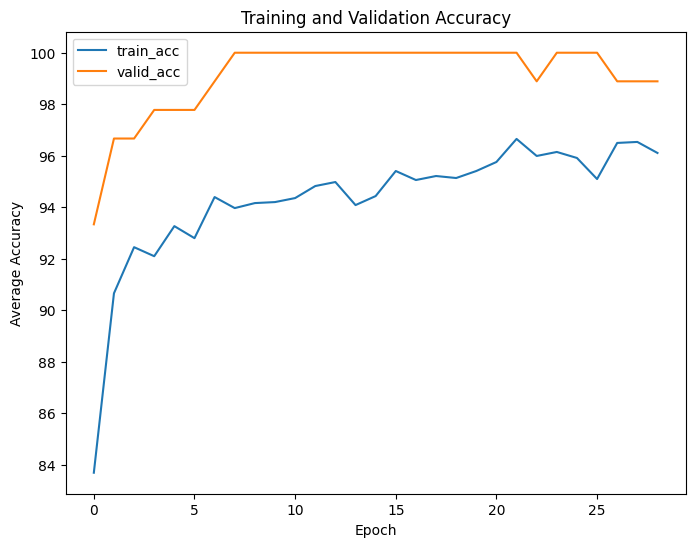

In [34]:
plt.figure(figsize=(8, 6))
for c in ['train_acc', 'valid_acc']:
    plt.plot(
        100 * history1[c], label=c)
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Average Accuracy')
plt.title('Training and Validation Accuracy')

Text(0.5, 1.0, 'Training and Validation Accuracy')

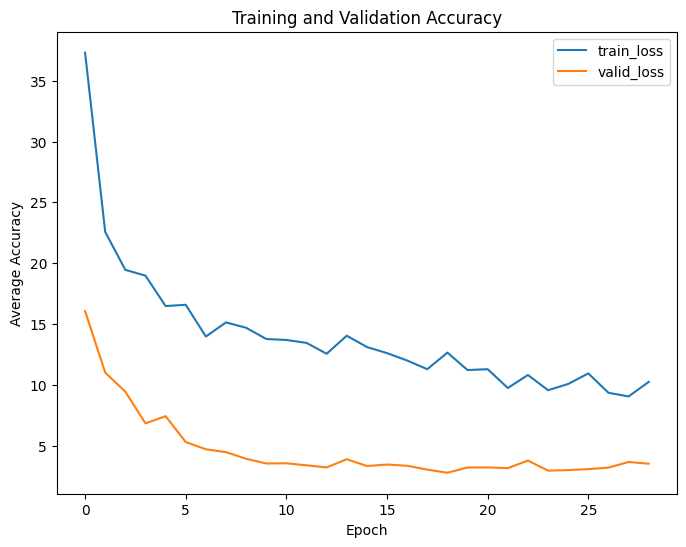

In [35]:
plt.figure(figsize=(8, 6))
for c in ['train_loss', 'valid_loss']:
    plt.plot(
        100 * history1[c], label=c)
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Average Accuracy')
plt.title('Training and Validation Accuracy')

In [30]:

def get_pretrained_model(model_name):

    if model_name == 'resnet34':
        model = models.resnet34(pretrained=True)

        # Freeze early layers
        for param in model.parameters():
            param.requires_grad = False
        model_aux3 = nn.Sequential(*list(model.children())[:-1])

        # Add on classifier
        model = nn.Sequential(model_aux3,
                              nn.Flatten(),
            nn.Linear(in_features=512, out_features= 254, bias= True), nn.ReLU(),
            nn.Linear(in_features=254, out_features= 2, bias= True), nn.LogSoftmax(dim=1))

    # Move to gpu and parallelize
    if torch.cuda.is_available():
        model = model.to('cuda')
    return model

model_resnet34 = get_pretrained_model('resnet34')
lr = 0.0001
summary(model_resnet34, input_size=(3, 224, 224), batch_size=batch_size, device='cuda')
optimizer = optim.Adam(model_resnet34.parameters(),lr=lr)

model3, history3 = train1(
    model_resnet34,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    save_file_name,
    max_epochs_stop=10,
    n_epochs=20,
    print_every=1)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [32, 64, 112, 112]           9,408
       BatchNorm2d-2         [32, 64, 112, 112]             128
              ReLU-3         [32, 64, 112, 112]               0
         MaxPool2d-4           [32, 64, 56, 56]               0
            Conv2d-5           [32, 64, 56, 56]          36,864
       BatchNorm2d-6           [32, 64, 56, 56]             128
              ReLU-7           [32, 64, 56, 56]               0
            Conv2d-8           [32, 64, 56, 56]          36,864
       BatchNorm2d-9           [32, 64, 56, 56]             128
             ReLU-10           [32, 64, 56, 56]               0
       BasicBlock-11           [32, 64, 56, 56]               0
           Conv2d-12           [32, 64, 56, 56]          36,864
      BatchNorm2d-13           [32, 64, 56, 56]             128
             ReLU-14           [32, 64,

Text(0.5, 1.0, 'Training and Validation Accuracy')

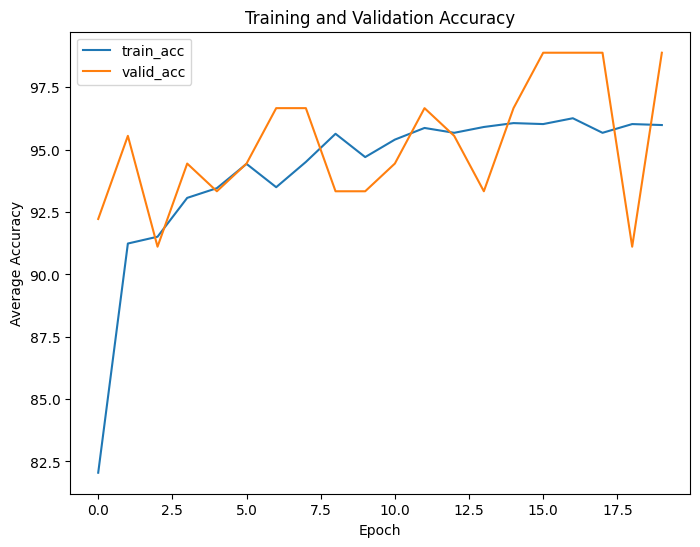

In [31]:
plt.figure(figsize=(8, 6))
for c in ['train_acc', 'valid_acc']:
    plt.plot(
        100 * history3[c], label=c)
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Average Accuracy')
plt.title('Training and Validation Accuracy')

In [ ]:
model3.cuda()

Text(0.5, 1.0, 'Training and Validation Losses')

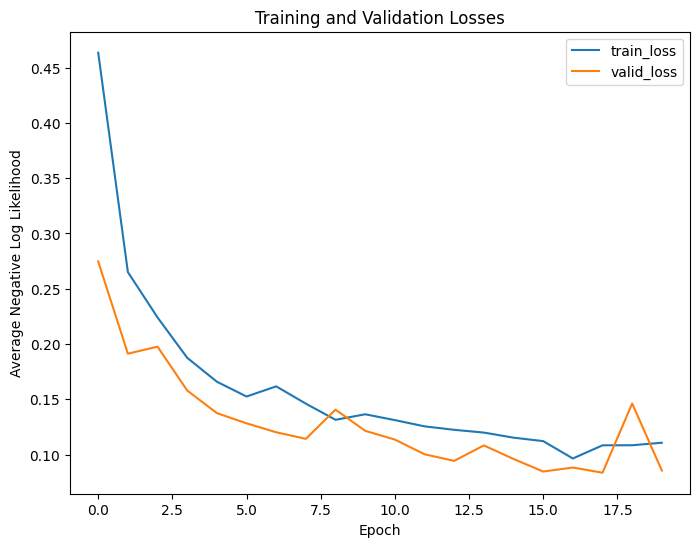

In [32]:
plt.figure(figsize=(8, 6))
for c in ['train_loss', 'valid_loss']:
    plt.plot(
        history3[c], label=c)
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Average Negative Log Likelihood')
plt.title('Training and Validation Losses')

Text(0.5, 1.0, 'Training and Validation Accuracy')

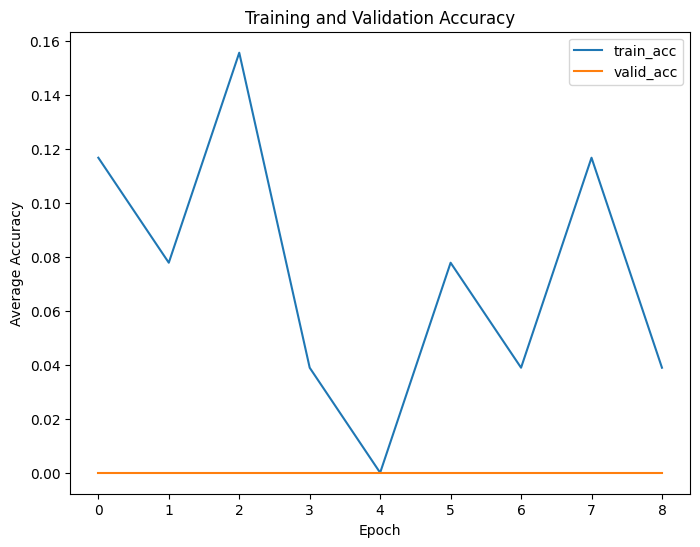

In [10]:
plt.figure(figsize=(8, 6))
for c in ['train_acc', 'valid_acc']:
    plt.plot(
        100 * history[c], label=c)
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Average Accuracy')
plt.title('Training and Validation Accuracy')

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(device)

def accuracy(model, loader):
    num_correct = 0
    num_total = 0
    model.eval()
    model = model.to(device=device)
    with torch.no_grad():
        for (xi, yi) in loader:
            xi = xi.to(device=device, dtype = torch.float32)
            yi = yi.to(device=device, dtype = torch.long)
            scores = model(xi) # mb_size, 10
            _, pred = scores.max(dim=1) #pred shape (mb_size )
            num_correct += (pred == yi).sum() # pred shape (mb_size), yi shape (mb_size, 1)
            num_total += pred.size(0)
        return float(num_correct)/num_total 
    
model_resnet18 = models.resnet18(pretrained=True)
        
for i, w in enumerate(model_resnet18.parameters()):
    print(i, w.shape, w.requires_grad)
    
model_aux = nn.Sequential(*list(model_resnet18.children())[:-1])

for i, parameter in enumerate(model_aux.parameters()):
    parameter.requires_grad = False

def train(model, optimiser, epochs=epochs):
    history = []
#     def train(model, optimiser, scheduler = None, epochs=100):
    model = model.to(device=device)
    overall_start = timer()
    
    for epoch in range(epochs):
        for i, (xi, yi) in enumerate(train_loader):
            model.train()
            start = timer()
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)

            cost = F.cross_entropy(input= scores, target=yi)
            
        
            optimiser.zero_grad()           
            cost.backward()
            optimiser.step()    
            
       
            
        acc_val = accuracy(model, val_loader)
        acc_train = accuracy(model, train_loader)
        history.append([cost.item(), acc_train, acc_val])
#         if epoch%5 == 0:     
        print(f'Epoch: {epoch}, costo: {cost.item()}, validation accuracy: {acc_val},train accuracy: {acc_train},')
        model.optimiser = optimiser
        # Record overall time and print out stats
        total_time = timer() - overall_start
        print(f'{total_time:.2f} total seconds elapsed. {total_time / (epoch):.2f} seconds per epoch.')
        
        history = pd.DataFrame(
        history,
        columns=['train_loss', 'train_acc', 'valid_acc'])
        return model, history


hidden1 = 256 
hidden = 256
lr = 5e-4
epochs = 50
# model1 = nn.Sequential(nn.Flatten(),
#                        nn.Linear(in_features=32*32*3, out_features=hidden1), nn.ReLU(),
#                        nn.Linear(in_features=hidden1, out_features=hidden), nn.ReLU(),
#                        nn.Linear(in_features=hidden, out_features=10))

model1 = nn.Sequential(model_aux,
                       nn.Flatten(), 
                       nn.Linear(in_features=512, out_features= 10, bias= True))
optimiser = torch.optim.Adam(model1.parameters(), lr=lr, betas=(0.9, 0.999))

modelo,history = train(model1, optimiser, epochs)


accuracy(model1, test_loader)










In [ ]:

'''  


#Loop de entrenamiento

def train(model, optimiser, epochs=100):
#     def train(model, optimiser, scheduler = None, epochs=100):
    model = model.to(device=device)
    for epoch in range(epochs):
        for i, (xi, yi) in enumerate(train_loader):
            model.train()
            xi = xi.to(device=device, dtype=torch.float32)
            yi[0] = yi.to(device=device, dtype=torch.long)
            scores = model(xi)

            cost = F.cross_entropy(input= scores, target=yi)
        
            optimiser.zero_grad()           
            cost.backward()
            optimiser.step()           
            
        acc = accuracy(model, val_loader)
#         if epoch%5 == 0:     
        print(f'Epoch: {epoch}, costo: {cost.item()}, accuracy: {acc},')
#         scheduler.step()

model_resnet18 = models.resnet18(pretrained=True)
model_vgg16 = models.vgg16(pretrained = True)


model_aux = nn.Sequential(*list(model_resnet18.children())[:-1])  # no incluimos la ultima capa del modelo
model_aux2 = nn.Sequential(*list(model_vgg16.children())[:-1])


for i, parameter in enumerate(model_aux2.parameters()):
    parameter.requires_grad = False              # congelamos el modelo actual.


hidden1 = 256 
hidden = 256
lr = 5e-4
epochs = 5
# model1 = nn.Sequential(nn.Flatten(),
#                        nn.Linear(in_features=32*32*3, out_features=hidden1), nn.ReLU(),
#                        nn.Linear(in_features=hidden1, out_features=hidden), nn.ReLU(),
#                        nn.Linear(in_features=hidden, out_features=10))


model1 = nn.Sequential(model_aux,
                       nn.Flatten(), 
                       nn.Linear(in_features=512, out_features= 10, bias= True))

optimiser = torch.optim.Adam(model1.parameters(), lr=lr, betas=(0.9, 0.999))

train(model1, optimiser, epochs)

accuracy(model1, test_loader)


model2 = nn.Sequential(model_aux2,
                       nn.Flatten(), 
                       nn.Linear(in_features=512, out_features= 10, bias= True))

optimiser = torch.optim.Adam(model2.parameters(), lr=lr, betas=(0.9, 0.999))
train(model2, optimiser, epochs)
accuracy(model2, test_loader)

'''

In [2]:
import torch
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(device)

cpu


In [4]:
Cuda:{'NVIDIA GeForce RTX 3060'} 

if torch.cuda.is_available(): 
 dev = "cuda:0" 
else: 
 dev = "cpu" 
device = torch.device(dev) 
a = torch.zeros(4,3) 
a = a.to(device)

https://robots.net/tech/how-to-use-gpu-with-pytorch/

In [2]:
import torch
torch.cuda.is_available()

True